In [1]:
import sys
sys.path.append('../')
import os.path as osp

import torch
from torch.utils.data import DataLoader
import numpy as np
import copy
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import utils
import utils.Camel.equations as equations

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE = 'cpu'
print(DEVICE)

cuda:0


/home/mdrnevich/dev/QuasiML_paper/QuasiML/ToyModels/../utils/__init__.py:5: UserWarning: The recommended fonts to use plothist were not found. You can install them by typing 'install_latin_modern_fonts' in your terminal. 

  from . import plotting


# Now create a combined model and optimize the coefficients

In [2]:
batch_size = int(2**8)
subdensity_model_paths = [osp.join("models/classifier_subdensity_{}_batch{}.zip".format(i+1, batch_size)) for i in range(4)]

In [3]:
FINE_TUNE = False

mix_model = utils.models.MixtureClassifier(subdensity_model_paths, fine_tune=FINE_TUNE).to(DEVICE)
print(mix_model)

MixtureClassifier(
  (subclassifiers): ModuleList(
    (0-3): 4 x Classifier(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): ReLU()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): ReLU()
        (4): Linear(in_features=32, out_features=1, bias=True)
        (5): Sigmoid()
      )
    )
  )
)


In [4]:
source_file = "./data/base_distribution_mc_data"
target_file = "./data/target_distribution_mc_data"

source_positive_file = source_file + "_positives"
source_negative_file = source_file + "_negatives"
target_positive_file = target_file + "_positives"
target_negative_file = target_file + "_negatives"

files = [source_positive_file, source_negative_file, target_positive_file, target_negative_file]

sum_weights = []
for f in files:
    sum_weights.append(np.load(f + "_train.npy")[:,-1].sum())

sum_weights = np.array(sum_weights)
sum_weights

array([1600424., -399576., 1333268., -666732.])

In [5]:
coefficient_init = [sum_weights[0] / sum_weights[:2].sum(), sum_weights[2] / sum_weights[2:].sum()]
coefficient_init

[1.3327448602987222, 2.0002940576352963]

In [6]:
mix_model.initialize(coefficient_init)
list(mix_model.parameters())

In initializing
Init vals:
[1.3327448602987222, 2.0002940576352963]
After init:
Parameter containing:
tensor(1.3327, requires_grad=True) Parameter containing:
tensor(2.0003, requires_grad=True)


[Parameter containing:
 tensor(1.3327, requires_grad=True),
 Parameter containing:
 tensor(2.0003, requires_grad=True),
 Parameter containing:
 tensor([[ 0.0253,  0.2397],
         [-0.6269, -0.5144],
         [-0.3601,  0.2541],
         [ 0.0032,  0.5844],
         [-0.0183,  0.1411],
         [-0.1673, -0.1450],
         [-0.7539, -0.4354],
         [-0.3016,  0.0791],
         [ 0.2638,  0.4672],
         [-0.4319, -0.3355],
         [ 0.2308,  0.6242],
         [-0.1035,  0.4424],
         [-0.0517,  0.0521],
         [ 0.7383, -0.7192],
         [-0.4261, -0.1933],
         [-0.3665,  0.6813],
         [-0.4865, -0.3608],
         [-0.5123, -0.6586],
         [-0.4329,  0.5930],
         [ 0.3936,  0.3855],
         [ 0.0263, -0.3678],
         [ 0.1494, -0.6861],
         [-0.5332, -0.3955],
         [ 0.5255,  0.4017],
         [-0.2087, -0.0457],
         [ 0.4870,  0.7348],
         [ 0.2480,  0.0477],
         [ 0.4645, -0.3723],
         [ 0.1502, -0.4406],
         [-0.407

In [7]:
training_settings_mix = {}

source_mixture_coef = (4, -1)
source_scales = (2.5, 2.3)
target_mixture_coef = (2, -1)
target_scales = (2, 1.2)


MIN_TRAIN_SIZE = int(min([np.load(source_file + "_train.npy").shape[0], np.load(target_file + "_train.npy").shape[0]]))
MIN_VALID_SIZE = int(min([np.load(source_file + "_val.npy").shape[0], np.load(target_file + "_val.npy").shape[0]]))

train_base_dataset = utils.preprocessing.Dataset(source_file + "_train.npy", 0, stop_event=MIN_TRAIN_SIZE)
valid_base_dataset = utils.preprocessing.Dataset(source_file + "_val.npy", 0, stop_event=MIN_VALID_SIZE)

train_target_dataset = utils.preprocessing.Dataset(target_file + "_train.npy", 1, stop_event=MIN_TRAIN_SIZE)
valid_target_dataset = utils.preprocessing.Dataset(target_file + "_val.npy", 1, stop_event=MIN_VALID_SIZE)

training_settings_mix.update({
    "source_file": source_file,
    "target_file": target_file,
    "source_mixture_coef": source_mixture_coef,
    "source_scales": source_scales,
    "target_mixture_coef": target_mixture_coef,
    "target_scales": target_scales
})

In [8]:
source_weight_norm = train_base_dataset.process(normalize_weights=True)
valid_base_dataset.process(normalize_weights=True)

target_weight_norm = train_target_dataset.process(normalize_weights=True)
valid_target_dataset.process(normalize_weights=True)

tensor(0.3343)

In [9]:
train_generator_data = utils.preprocessing.CombinedDataset(train_base_dataset, train_target_dataset)
valid_generator_data = utils.preprocessing.CombinedDataset(valid_base_dataset, valid_target_dataset)

In [10]:
X_scaler, train_weight_norm = utils.preprocessing.get_scaling(train_generator_data)
_, valid_weight_norm = utils.preprocessing.get_scaling(valid_generator_data)
print(train_weight_norm, valid_weight_norm)

100%|██████████| 1172/1172 [00:07<00:00, 146.96it/s]

tensor(1.0000) tensor(1.0000)


### Save the plain SMM model

In [11]:
SAVE_SMM = False

if SAVE_SMM is True:
    SMM_model = utils.models.MixtureClassifier(subdensity_model_paths, t0=t0, t1=t1, fine_tune=False).to(DEVICE)
    SMM_model.initialize(coefficient_init)
    model_path = osp.join("models/classifier_SMM_batch{}".format(batch_size))
    model_metadata = utils.train.get_model_metadata(training_settings_mix, SMM_model, X_scaler, train_weight_norm)
    utils.train.save_model_data(SMM_model, model_metadata, name=model_path, save_onnx=False, device=DEVICE)

### Now optimize the coefficients

In [12]:
random_seed = 0

torch.manual_seed(random_seed)

train_loader = DataLoader(train_generator_data, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_generator_data, batch_size=batch_size, shuffle=False)

In [13]:
learning_rate = 1e-4
optimizer = torch.optim.Adam(mix_model.parameters(), lr=learning_rate)

# Get the analytical optimal classifier
def qdre_score_function(ratio):
    return (ratio + 2 - np.sqrt(ratio**2 + 4)) / (2*ratio)

r_optimal = equations.optimal_likelihood_ratio(source_mixture_coef, source_scales, target_mixture_coef, target_scales)
s_optimal = lambda x: qdre_score_function(r_optimal(x))

if FINE_TUNE is False:
    model_path = osp.join("models/classifier_SMMc_qdre_batch{}".format(batch_size))
else:
    model_path = osp.join("models/classifier_SMMr_qdre_batch{}".format(batch_size))

In [14]:
n_epochs = 1500
stale_epochs = 0
best_valid_loss = 99999
patience = 10
max_num_batches = int(int(1e5) / batch_size)
t = tqdm(range(0, n_epochs))

training_losses = [utils.train.test(
        mix_model,
        train_loader,
        weight_norm=train_weight_norm,
        loss='qdre',
        SMM=True,
        device=DEVICE,
        max_num_batches=max_num_batches,
        progress_bar=False,
        leave=False
    )[0],]
validation_losses = [utils.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='qdre',
        SMM=True,
        device=DEVICE,
        progress_bar=False,
        leave=False
    )[0],]

optimal_train_loss = utils.train.get_optimal_loss(
        s_optimal,
        train_loader,
        weight_norm=train_weight_norm,
        loss='qdre',
        device=DEVICE,
        progress_bar=False
)
optimal_valid_loss = utils.train.get_optimal_loss(
        s_optimal,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='qdre',
        device=DEVICE,
        progress_bar=False
)

training_settings_mix.update({
    "optimal_train_loss": optimal_train_loss,
    "optimal_valid_loss": optimal_valid_loss
})

for epoch in t:
    loss = utils.train.train(
        mix_model,
        optimizer,
        train_loader,
        weight_norm=train_weight_norm,
        max_num_batches=max_num_batches,
        loss='qdre',
        SMM=True,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #loss -= optimal_train_loss
    training_losses.append(loss[0])

    valid_loss = utils.train.test(
        mix_model,
        valid_loader,
        weight_norm=valid_weight_norm,
        loss='qdre',
        SMM=True,
        device=DEVICE,
        progress_bar=False,
        leave=bool(epoch == n_epochs - 1),
    )
    #valid_loss -= optimal_valid_loss
    validation_losses.append(valid_loss[0])
    print("Epoch: {:02d}, Training Loss:   {:.4f}".format(epoch, loss[1]))
    print("           Validation Loss: {:.4f}".format(valid_loss[1]))

    if valid_loss[1] < best_valid_loss:
        best_valid_loss = valid_loss[1]
        print("New best model with parameters:", mix_model.coefficients)
        training_settings_mix.update({
            "n_epochs": epoch+1,
            "training_losses": training_losses,
            "validation_losses": validation_losses
        })
        model_metadata = utils.train.get_model_metadata(training_settings_mix, mix_model, X_scaler, train_weight_norm)
        utils.train.save_model_data(mix_model, model_metadata, name=model_path, save_onnx=False, device=DEVICE)
        print("New best model saved to: {}.zip".format(model_path))
        stale_epochs = 0
    else:
        print("Stale epoch")
        stale_epochs += 1
    if stale_epochs >= patience:
        print("Early stopping after %i stale epochs" % patience)
        break

  0%|          | 0/1500 [00:00<?, ?it/s]

Epoch: 00, Training Loss:   0.8953
           Validation Loss: 0.8986
New best model with parameters: (1.3319464921951294, 2.0022008419036865)
New best model saved to: models/classifier_SMMc_qdre_batch256.zip
Epoch: 01, Training Loss:   0.8899
           Validation Loss: 0.8986
New best model with parameters: (1.3303380012512207, 2.0023033618927)
New best model saved to: models/classifier_SMMc_qdre_batch256.zip
Epoch: 02, Training Loss:   0.9022
           Validation Loss: 0.8986
New best model with parameters: (1.3274004459381104, 2.001413345336914)
New best model saved to: models/classifier_SMMc_qdre_batch256.zip
Epoch: 03, Training Loss:   0.8900
           Validation Loss: 0.8986
New best model with parameters: (1.322088599205017, 2.000401258468628)
New best model saved to: models/classifier_SMMc_qdre_batch256.zip
Epoch: 04, Training Loss:   0.8940
           Validation Loss: 0.8986
New best model with parameters: (1.3167617321014404, 1.9993878602981567)
New best model saved to: mo

## Look at the loss curves

Text(0, 0.5, 'BCE Loss')

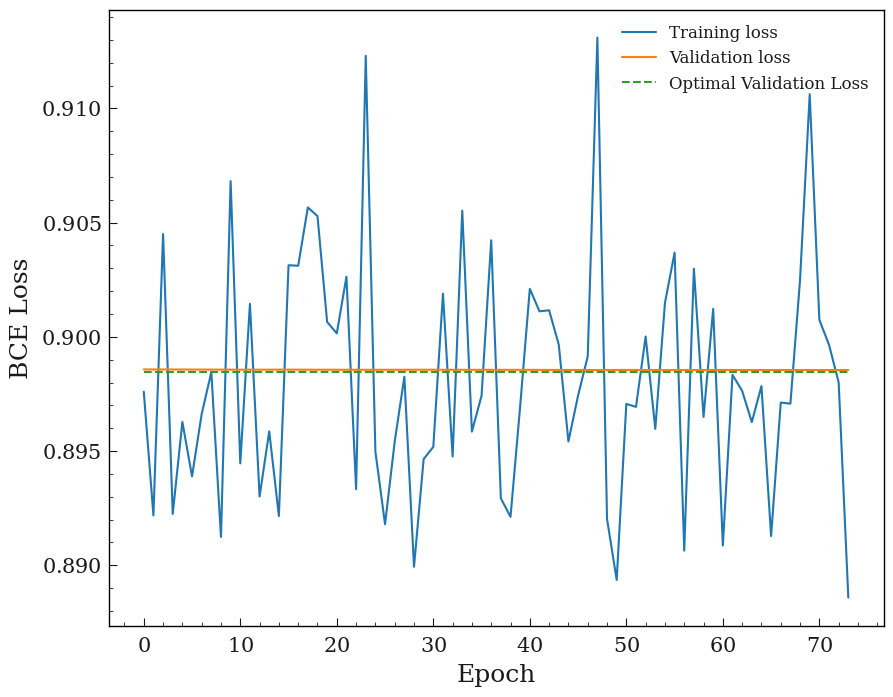

In [15]:
fig,ax = plt.subplots()
fig.set_size_inches(10, 8)

starting_epoch = 1
training_loss_per_epoch = np.array(training_losses[starting_epoch:]).mean(axis=1)
training_std_per_epoch = np.array(training_losses[starting_epoch:]).std(axis=1)

validation_loss_per_epoch = np.array(validation_losses[starting_epoch:]).mean(axis=1)
validation_std_per_epoch = np.array(validation_losses[starting_epoch:]).std(axis=1)

training_lower_bar = training_loss_per_epoch - training_std_per_epoch
training_upper_bar = training_loss_per_epoch + training_std_per_epoch

validation_lower_bar = validation_loss_per_epoch - validation_std_per_epoch
validation_upper_bar = validation_loss_per_epoch + validation_std_per_epoch


t1 = np.arange(len(training_loss_per_epoch))
t2 = np.arange(len(validation_loss_per_epoch))
ax.plot(t1, training_loss_per_epoch, '-', label="Training loss", c='tab:blue')
#ax.fill_between(t1, training_lower_bar, training_upper_bar, color='tab:blue', alpha=0.30)

ax.plot(t2, validation_loss_per_epoch, '-', label="Validation loss", c='tab:orange')
#ax.fill_between(t2, validation_lower_bar, validation_upper_bar, color='tab:orange', alpha=0.30)

ax.plot([0, max([t1.max(), t2.max()])], [training_settings_mix["optimal_valid_loss"]]*2, '--', color='tab:green', label="Optimal Validation Loss")
#ax.plot([0, max([t1.max(), t2.max()])], [training_settings_mix["optimal_train_loss"]]*2, '--', color='tab:green', label="Optimal Training Loss")

#ax.set_xscale('log')
ax.legend()
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")